### Implementing simple chatbot using Langgraph

In [1]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END

## Reducers
from typing import Annotated
from langgraph.graph.message import add_messages


In [2]:
class State(TypedDict):
    messages:Annotated[list, add_messages]

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [4]:
from langchain_groq import ChatGroq
llm = ChatGroq(model="qwen/qwen3-32b")
ans = llm.invoke("Hello, how are you?")
ans.content

"<think>\nOkay, the user is greeting me with a Hello and asking how I am. I should respond with a friendly greeting in return.\n\nI need to make sure my response is warm and inviting. Maybe add an emoji to keep it light and approachable.\n\nAlso, since they asked how I am, I can mention I'm doing well and ready to help. Then, ask how I can assist them. Keep the tone conversational and helpful.\n</think>\n\nHello! I'm doing well, thank you! 😊 How can I assist you today?"

### We will start creating nodes

In [5]:
def superbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}

In [6]:
graph = StateGraph(State)

## node
graph.add_node("Superbot", superbot)

## edges
graph.add_edge(START, "Superbot")
graph.add_edge("Superbot", END)

## compile
graph_builder = graph.compile()


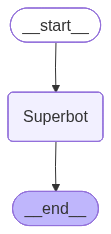

In [7]:
from IPython.display import display,Image
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [8]:
## Invocation

graph_builder.invoke({"messages":"Hello, how are you?"})

{'messages': [HumanMessage(content='Hello, how are you?', additional_kwargs={}, response_metadata={}, id='6d4355c9-6c66-41a0-bc6d-22061d6aad9d'),
  AIMessage(content='<think>\nOkay, the user just greeted me with "Hello, how are you?" I need to respond in a friendly and welcoming way. Since I\'m an AI, I don\'t have feelings, but I should acknowledge their greeting. Let me start with a cheerful "Hi!" to match their tone. Then, I should mention that I\'m an AI and don\'t have feelings, but I\'m here to help. It\'s important to invite them to ask questions or share what\'s on their mind to encourage further conversation. Keep the response simple and approachable. Maybe add an emoji to keep it friendly. Let me put that all together.\n</think>\n\nHi! 😊 I\'m an AI, so I don\'t have feelings, but I\'m here and ready to help! How can I assist you today? Feel free to ask questions or share what\'s on your mind!', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 177,

### Stream the responses

In [9]:
for event in graph_builder.stream({"messages":"Hello, I am Adarsh?"}):
    print(event)

{'Superbot': {'messages': [AIMessage(content="<think>\nOkay, the user introduced himself as Adarsh. I should respond warmly and ask how I can assist him.\n\nFirst, I need to acknowledge his introduction and offer help, maybe ask what specific questions or needs he has.\n\nAlso, considering he might be looking for information, solving a problem, or just wants to chat, I should keep the response friendly and open-ended to encourage him to share more.\n\nMake sure the response is concise and clear, avoiding any technical jargon. Just a simple greeting and offer of assistance.\n</think>\n\nHello Adarsh! Nice to meet you. How can I assist you today? Feel free to ask me any questions or let me know if there's something specific you'd like help with. 😊", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 151, 'prompt_tokens': 16, 'total_tokens': 167, 'completion_time': 0.342565608, 'completion_tokens_details': None, 'prompt_time': 0.000688952, 'prompt_tokens_details